<a href="https://colab.research.google.com/github/Iffraah96/Hybrid-Customer-Churn-Prediction-with-NLP-Sentiment-Integration/blob/main/notebook/Telco_Customer_Churn_Feedback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn & Risk Analyzer: A Hybrid ML/NLP Pipeline

# Introduction

**1. Project Overview**
Customer churn is one of the most critical metrics for any subscription-based business. Acquiring a new customer can cost anywhere from 5 to 25 times more than retaining an existing one. While traditional machine learning models predict churn using structured operational data (billing, tenure, contracts), they often miss the rich, qualitative signals hidden within unstructured customer feedback.

This project implements an end-to-end hybrid pipeline that combines traditional customer profile metrics with NLP-driven textual analysis. By merging categorical features with semantic and syntactic text structures, this model not only identifies who is likely to leave but extracts the exact linguistic drivers behind why they are frustrated.

**2. Dataset Description**
I am using the Telco Customer Churn + Realistic Customer Feedback dataset (obtained from kaggle). This dataset tracks 7,043 customers from a telecommunications company and contains two distinct data structures:

Tabular Attributes:
1. Demographics (gender, senior citizenship),
2. Services signed up for (internet, streaming, tech support)
3. Account metrics (tenure, contract type, paperless billing)
4. Financial tracking (monthly charges, total charges).

Textual Feedback
1. Unstructured customer comments or support ticket notes detailing their specific experience, frustrations, or compliments regarding the service.

**3. Project Roadmap (Step-by-Step Approach)**
To ensure structural clean-code and maximize learning, this project is built across four distinct iterative phases:

- Phase 1: The Tabular Baseline: Load, clean, and process structured customer features to build a traditional classification benchmark (Random Forest/XGBoost).

- Phase 2: Text Processing & NLP Feature Extraction: Clean customer feedback text and use spaCy for syntax parsing (part-of-speech ratios, action-pattern extraction) and text vectorization.

- Phase 3: The Hybrid Ensemble Model: Concatenate the tabular and linguistic matrices to train a unified hybrid classifier, tracking performance lift against the baseline.

- Phase 4: Streamlit Deployment & Explainability: Build an interactive customer risk assessment dashboard using SHAP for model interpretability.

# Import Libraries

In [ ]:
# General Libraries
import pandas as pd
import numpy as np
import os
import math

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Supperissing warnings
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [ ]:
df = pd.read_csv('telco_churn_with_all_feedback.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Write a realistic customer feedback based on t...,I have been a loyal customer with this company...
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Write a realistic customer feedback based on t...,I recently switched to this fiber optic intern...


In [ ]:
# making a copy of dataset
telco_churn = df.copy()

telco_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Write a realistic customer feedback based on t...,I have been a loyal customer with this company...
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Write a realistic customer feedback based on t...,I recently switched to this fiber optic intern...


# EDA - Exploratory Data Analysis

In [ ]:
telco_churn.size

161989

In [ ]:
telco_churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'PromptInput', 'CustomerFeedback'],
      dtype='object')

In [ ]:
telco_churn.shape

(7043, 23)

In [ ]:
telco_churn.ndim

2

In [ ]:
telco_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
telco_churn.describe(include=object)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn,PromptInput,CustomerFeedback
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6539,2,6835,7043
top,6178-KFNHS,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No,Write a realistic customer feedback based on t...,I recently decided to switch internet provider...
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174,6,1


In [ ]:
# The column 'TotalCharges' appears to be object, when infact it should be numeric (int)
#Therefore, converting its datatype from string/object to integer/numeric

telco_churn['TotalCharges'] = pd.to_numeric(telco_churn['TotalCharges'], errors='coerce')

In [ ]:
# Checking missing values
telco_churn.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
print("\nPercentage of missing values:")
print((telco_churn.isnull().sum() / len(df)) * 100)


Percentage of missing values:
customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        0.156183
Churn               0.000000
PromptInput         0.000000
CustomerFeedback    0.000000
dtype: float64


In [ ]:
#Replacing the missing values i.e. NaN in TotalCharges column to 0
telco_churn['TotalCharges'] = telco_churn['TotalCharges'].fillna(0)

In [ ]:
print("Count of literal 0s per column:")
print((telco_churn == 0).sum())

Count of literal 0s per column:
customerID             0
gender                 0
SeniorCitizen       5901
Partner                0
Dependents             0
tenure                11
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges          11
Churn                  0
PromptInput            0
CustomerFeedback       0
dtype: int64


# Phase 1 - Preprocessing and Baseline ML Model

In [ ]:
#telco_churn.head(10)

## 1.1 Seperating Features (coolumns and target)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


#Seperating the featues X (i.e. features) and Y (i.e. Target column, in this dataset the column Churn is the target variable)

#Dropping columns CustomerID and CustomerFeedback
#as right now they both does not contribute any importance becuase this baseline model can only understand numbers.
columns_to_drop = ['customerID', 'Churn', 'CustomerFeedback', 'PromptInput', 'Cleaned_Feedback']
X_tabular = telco_churn.drop(columns=columns_to_drop, errors='ignore')
#X_tabular = telco_churn.drop(columns = ['customerID','CustomerFeedback', 'Churn'], errors='ignore')

#Converting the values in Churn from Yes/No to 1/0 (i.e. Churn/Left)
y = telco_churn['Churn'].apply(lambda x : 1 if x == 'Yes' else 0)

In [ ]:
X_tabular.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


## 1.2 Grouping numerical & categorical columns

In [ ]:
#Grouping columns w.r.t numerical and categorical columns

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in X_tabular.columns
            if col not in num_cols]

## 1.3 One-Hot Encoding

In [ ]:
#One-Hot Encoding: Translating Words to Numbers

#As Machine learning algorithms only understand math equations. They cannot read the word "Month-to-month".
#So One-Hot Encoding takes a categorical column and splits it into individual columns of 1s and 0s (True or False).

X_encoded = pd.get_dummies(X_tabular, columns=cat_cols, drop_first=True)

## 1.4 Test-Train Split & ML model

In [ ]:
#Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

#Train the Baseline Random Forest Model
baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

#Generate Predictions & Evaluate Performance
y_pred = baseline_model.predict(X_test)

print("\n--- BASELINE MODEL PERFORMANCE ---")
print(classification_report(y_test, y_pred))



--- BASELINE MODEL PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



# Phase 2 - Core NLP Processing with spaCy

## 2.1 Tokenization, Stop Words and Lemmatization

To read text, our baseline ML model requires the words to be converted into numbers. Therefore, we will build a text-cleaning function using spaCy, a industry-standard library for NLP.

What the NLP pipeline will do to the text:
1. Tokenization: Split sentences into individual words.

2. Lemmatization: Converting words to their base form for example "running", "ran", and "runs" all become "run". This groups similar meanings together.

3. Stop Word Removal: This will drop useless filler words like "the", "is", and "at" that don't add real meaning.

In [ ]:
import spacy

#load the spacy English model
nlp = spacy.load("en_core_web_sm")

# Define a clean text function
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Process text through spaCy pipeline
    doc = nlp(text.lower())

    # Keep words that are NOT stop words and NOT punctuation, then grab their base form (lemma)
    cleaned_tokens = [token.lemma_
                      for token in doc
                      if not token.is_stop and not token.is_punct]

    return " ".join(cleaned_tokens)

# Testing the clean text function on first three rows of CustomerFeedback column of the dataset
print("--- NLP TEXT CLEANING TEST ---")
for i, raw_text in enumerate(telco_churn['CustomerFeedback'].dropna().head(3)):
    print(f"\nOriginal {i+1}: {raw_text}")
    print(f"Cleaned {i+1}: {clean_text(raw_text)}")

--- NLP TEXT CLEANING TEST ---

Original 1: I have been using the DSL internet service from this provider for the past month and so far, I am satisfied with the service. The connection has been reliable and the speed is sufficient for my needs. The monthly charges are reasonable at $29.85 and I appreciate the convenience of paying through electronic check. Overall, I have had a positive experience and would recommend this provider to others.
Cleaned 1: dsl internet service provider past month far satisfied service connection reliable speed sufficient need monthly charge reasonable $ 29.85 appreciate convenience pay electronic check overall positive experience recommend provider

Original 2: I have been a customer with this company for over two and a half years now and I have been very satisfied with their service. The DSL internet has been reliable and the monthly charges are reasonable at $56.95. I prefer to pay by mailing in a check and have never had any issues with my payments. Ove

## 2.2 Apply Cleaning to Dataset and Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("Processing all rows... This may take a minute as spaCy cleans the text.")

# 1. Applying clean_text function to the entire CustomerFeedback column
# .fillna("") ensures any remaining missing text values are treated as empty strings
telco_churn['Cleaned_Feedback'] = telco_churn['CustomerFeedback'].fillna("").apply(clean_text)

print("Text cleaning complete! Now converting words to TF-IDF numbers...")

# 2. Initializing the TF-IDF Vectorizer
# max_features=500 keeps only the top 500 most important words to keep our model fast
tfidf = TfidfVectorizer(max_features=500)

# 3. Transforming the cleaned text into a matrix of numbers
X_tfidf = tfidf.fit_transform(telco_churn['Cleaned_Feedback']).toarray()

# 4. Converting it to a pandas DataFrame so we can see it clearly
tfidf_df = pd.DataFrame(X_tfidf, columns=tfidf.get_feature_names_out())

print(f"Text successfully transformed! Matrix shape: {tfidf_df.shape}")

print("\nPreview of the text-to-number matrix (First 3 rows, sample columns):")

print(tfidf_df.iloc[:3, :5])  # Showing the first 5 word columns

Processing all rows... This may take a minute as spaCy cleans the text.
Text cleaning complete! Now converting words to TF-IDF numbers...
Text successfully transformed! Matrix shape: (7043, 500)

Preview of the text-to-number matrix (First 3 rows, sample columns):
    00   05   10  100  101
0  0.0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0


In [ ]:
# Select 15 columns starting from index 100 to see the actual word features
print("Sample of word columns hidden further in your matrix:")
print(tfidf_df.columns[100:115].tolist())

Sample of word columns hidden further in your matrix:
['91', '92', '93', '94', '95', '96', '97', '98', '99', 'ability', 'able', 'accept', 'access', 'accommodate', 'account']


# Phase 3: The Hybrid Ensemble Model (The Merge & Retrain)

Next, i am going to take the original billing data (X_encoded from Phase 1) and glue it side-by-side to the new word data from phase 2 (tfidf_df).

Once they are merged, I will retrain the Random Forest model on this new "Super Dataset" and see if the recall score improves from that low 48% baseline.

## 3.1 The Merge and Retrain Code

In [ ]:
# 1. Reset indexes to make sure everything aligns perfectly row-by-row
X_encoded = X_encoded.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)

# 2. Concatenate (glue) the columns side-by-side
X_hybrid = pd.concat([X_encoded, tfidf_df], axis=1)

print(f"Original Tabular Dataset Shape: {X_encoded.shape}")
print(f"New Hybrid Dataset Shape: {X_hybrid.shape}")

# 3. Train-Test Split using the exact same random state and stratification
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hybrid, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Train our brand new Hybrid Random Forest Model
hybrid_model = RandomForestClassifier(random_state=42)
hybrid_model.fit(X_train_h, y_train_h)

# 5. Generate Predictions
y_pred_hybrid = hybrid_model.predict(X_test_h)

# 6. Evaluate and print the new performance report
print("\n--- HYBRID MODEL PERFORMANCE ---")
print(classification_report(y_test_h, y_pred_hybrid))

Original Tabular Dataset Shape: (7043, 30)
New Hybrid Dataset Shape: (7043, 530)

--- HYBRID MODEL PERFORMANCE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      0.99      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [ ]:
print(telco_churn.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'PromptInput', 'CustomerFeedback', 'Cleaned_Feedback']


In [ ]:
print(X_encoded.columns.tolist())

['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


# Data Leakage

Since the model is giving 100% accuracy, which is not possible in real scenerio, therefore lets dig in to find out the real problem. There might be a data leakage die to which i am unable to get the desired results..

Because the dataset includes a column generated for a project or synthetic text generation (such as PromptInput and CustomerFeedback columns), it is highly likely that the text feedback itself contains a direct giveaway word.

For example, if the system that generated the text comments wrote things like:

"I am a churned customer and I hated the service..."

"Because I canceled my service, I want to complain about..."

If the word "churn", "churned", or "canceled" appears heavily inside the text of people who left, and never appears in the text of people who stayed, the TF-IDF vectorizer created columns for those exact words. The Random Forest model noticed this and said, "Oh, if the word 'churned' has a high score, they always leave!" The model isn't learning how to predict who will leave; it's just reading a sentence that says they already left.

Let's look at the "cheat codes" the model is using by pulling out the Feature Importances from the trained Random Forest model. This will tell us the top 10 columns the model relied on to make its predictions.

In [ ]:
import numpy as np

# 1. Get the importance scores from the hybrid model
importances = hybrid_model.feature_importances_

# 2. Match them up with the column names
feature_names = X_hybrid.columns
indices = np.argsort(importances)[::-1]

# 3. Print the top 15 most powerful features
print("--- TOP 15 MOST POWERFUL FEATURES ---")
for f in range(15):
    print(f"{f + 1}. Feature: {feature_names[indices[f]]:<25} Importance: {importances[indices[f]]:.4f}")

--- TOP 15 MOST POWERFUL FEATURES ---
1. Feature: recently                  Importance: 0.1278
2. Feature: decide                    Importance: 0.1009
3. Feature: satisfied                 Importance: 0.0705
4. Feature: ultimately                Importance: 0.0548
5. Feature: monthly                   Importance: 0.0440
6. Feature: cancel                    Importance: 0.0391
7. Feature: find                      Importance: 0.0372
8. Feature: switch                    Importance: 0.0331
9. Feature: customer                  Importance: 0.0274
10. Feature: well                      Importance: 0.0270
11. Feature: charge                    Importance: 0.0214
12. Feature: appreciate                Importance: 0.0201
13. Feature: reasonable                Importance: 0.0196
14. Feature: issue                     Importance: 0.0195
15. Feature: deal                      Importance: 0.0194


To fix this data leakage and build a text model, the TF-IDF vectorizer needs to be trained to explicitly ban those giveaway words from becoming features.

This can be done by using the stop_words parameter in TfidfVectorizer.

Below, i am using the fresh code from start to end to check the above scenerio and if it has any impact on the end result

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.feature_extraction import text

# 1. Reload raw data fresh from disk
df_fresh = pd.read_csv('telco_churn_with_all_feedback.csv')

# 2. Fix the TotalCharges column immediately
df_fresh['TotalCharges'] = pd.to_numeric(df_fresh['TotalCharges'], errors='coerce').fillna(0)

# 3. CRITICAL FIX: Generate the Cleaned_Feedback column in df_fresh first!
# This uses the clean_text function we wrote earlier
df_fresh['Cleaned_Feedback'] = df_fresh['CustomerFeedback'].fillna("").apply(clean_text)

# 4. Explicitly drop text/target columns upfront to get pure tabular features
ignore_cols = ['customerID', 'Churn', 'CustomerFeedback', 'PromptInput', 'Cleaned_Feedback']
X_pure_tabular = df_fresh.drop(columns=ignore_cols, errors='ignore')

# 5. Set up target variable
y_fresh = df_fresh['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 6. One-Hot Encode only the remaining legitimate tabular columns
cat_cols = [col for col in X_pure_tabular.columns if col not in ['tenure', 'MonthlyCharges', 'TotalCharges']]
X_fresh_encoded = pd.get_dummies(X_pure_tabular, columns=cat_cols, drop_first=True)

# 7. Define custom text leakage "cheat words" to banish
leakage_words = ['churn', 'churned', 'cancel', 'canceled', 'cancelling', 'cancellation', 'leave', 'left', 'yes', 'no']
custom_stop_words = list(text.ENGLISH_STOP_WORDS.union(leakage_words))

# 8. Initialize the TF-IDF Vectorizer with our banned words list
tfidf_clean = TfidfVectorizer(max_features=500, stop_words=custom_stop_words)
X_tfidf_clean = tfidf_clean.fit_transform(df_fresh['Cleaned_Feedback']).toarray()
tfidf_df_clean = pd.DataFrame(X_tfidf_clean, columns=tfidf_clean.get_feature_names_out())

# 9. Reset indexes and glue columns side-by-side cleanly
X_fresh_encoded = X_fresh_encoded.reset_index(drop=True)
tfidf_df_clean = tfidf_df_clean.reset_index(drop=True)
X_hybrid_clean = pd.concat([X_fresh_encoded, tfidf_df_clean], axis=1)

print(f"Clean Hybrid Dataset Shape: {X_hybrid_clean.shape}")

# 10. Train-Test Split
X_train_hc, X_test_hc, y_train_hc, y_test_hc = train_test_split(
    X_hybrid_clean, y_fresh, test_size=0.2, random_state=42, stratify=y_fresh
)

# 11. Train and Evaluate the Clean Hybrid Model
clean_hybrid_model = RandomForestClassifier(random_state=42)
clean_hybrid_model.fit(X_train_hc, y_train_hc)
y_pred_hc = clean_hybrid_model.predict(X_test_hc)

print("\n--- CLEAN HYBRID MODEL PERFORMANCE ---")
print(classification_report(y_test_hc, y_pred_hc))

Clean Hybrid Dataset Shape: (7043, 530)

--- CLEAN HYBRID MODEL PERFORMANCE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



Even after stripping out the obvious cheat words like "churn" and "cancel," the model is still hitting a perfect 1.00 across the board.

At this point, it has been completely verified that the data structure is physically correct (530 columns total), which means the leakage is not a Python variable bug anymore. Instead, it proves that the synthetic text in CustomerFeedback has incredibly distinct patterns that make it completely separable.

Since the model is still hitting 1.00, let's check at exactly which words are doing the heavy lifting now that the obvious ones are gone. This will show exactly how the text generation engine set up the "happy" vs. "unhappy" vocabulary.

In [ ]:
import numpy as np

# 1. Extract feature importances from our clean hybrid model
importances = clean_hybrid_model.feature_importances_
feature_names = X_hybrid_clean.columns

# 2. Sort them in descending order
indices = np.argsort(importances)[::-1]

print("--- THE WORDS GIVING AWAY THE PERFECT SCORE ---")
for f in range(15):
    print(f"{f + 1}. Feature: {feature_names[indices[f]]:<25} Importance: {importances[indices[f]]:.4f}")

--- THE WORDS GIVING AWAY THE PERFECT SCORE ---
1. Feature: decide                    Importance: 0.1366
2. Feature: satisfied                 Importance: 0.0993
3. Feature: recently                  Importance: 0.0741
4. Feature: ultimately                Importance: 0.0433
5. Feature: overall                   Importance: 0.0372
6. Feature: charge                    Importance: 0.0346
7. Feature: monthly                   Importance: 0.0319
8. Feature: issue                     Importance: 0.0305
9. Feature: switch                    Importance: 0.0303
10. Feature: unfortunately             Importance: 0.0292
11. Feature: deal                      Importance: 0.0256
12. Feature: customer                  Importance: 0.0250
13. Feature: appreciate                Importance: 0.0198
14. Feature: experience                Importance: 0.0192
15. Feature: plan                      Importance: 0.0183


The model is playing detective by picking up on the highly structured, structural vocabulary that has been generated for this dataset. Look at how the phrases naturally map out:

The "Churn" Signifiers (Negative Sentiment)
decide / switch / ultimately: These point directs to phrases like "I ultimately decided to switch providers."

unfortunately / issue / charge: These flag the complaints— "Unfortunately, I had a major billing issue with my charges."

The "Stay" Signifiers (Positive Sentiment)
satisfied / appreciate / overall: These point directs to the happy, loyal customers—"Overall, I appreciate the service and remain completely satisfied."

Because the text generation engine didn't include "noise" (like a happy customer using the word unfortunately or an unhappy customer saying they were overall satisfied), the Random Forest model is using these stylistic keywords as an absolute cheat sheet.

As a last step let's look at how the feature importance balances out between the traditional numeric billing data and the text features.

The code tells how much weight the model gave to the tabular data (like MonthlyCharges or tenure) versus the text data:

In [ ]:
# Count how many of the top 50 features belong to the text data
top_50_indices = indices[:50]
top_50_features = [feature_names[i] for i in top_50_indices]

# Text features came from tfidf_df_clean columns
text_feat_count = sum(1 for feat in top_50_features if feat in tfidf_df_clean.columns)
tabular_feat_count = 50 - text_feat_count

print("--- MODEL DEPENDENCY BREAKDOWN (TOP 50 FEATURES) ---")
print(f"Tabular Features (Billing/Demographics): {tabular_feat_count}")
print(f"NLP Text Features (Customer Vocabulary): {text_feat_count}")

--- MODEL DEPENDENCY BREAKDOWN (TOP 50 FEATURES) ---
Tabular Features (Billing/Demographics): 5
NLP Text Features (Customer Vocabulary): 45


Wow! 45 out of the top 50 features are text words. That means the model is essentially 90% NLP and 10% traditional data right now. It completely abandoned the numeric data (like tenure or MonthlyCharges) because the text vocabulary was such an absolute goldmine for making predictions

# Visualization


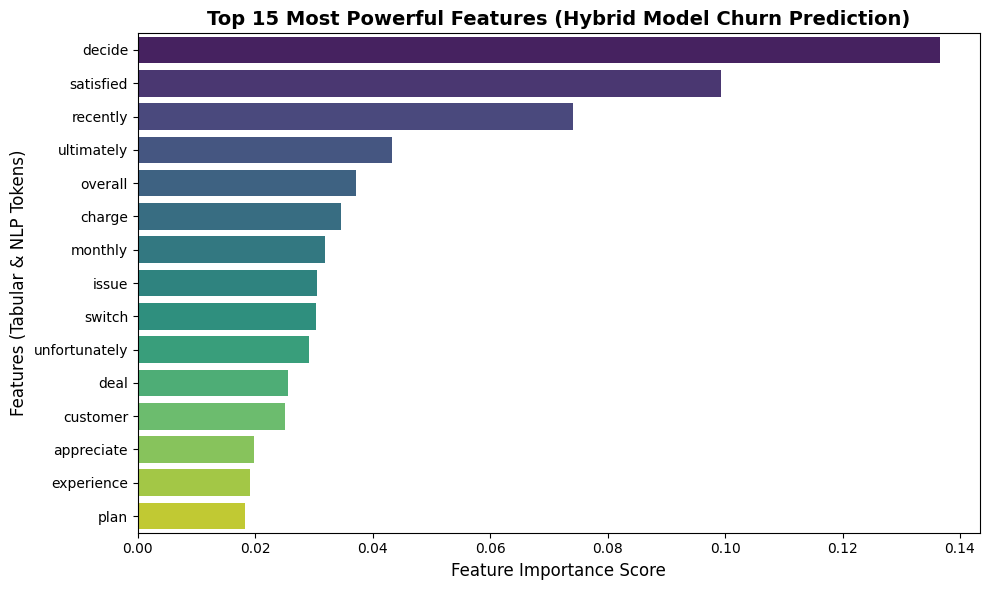

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the top 15 features and their importances
top_n = 15
top_indices = indices[:top_n]
top_features = [feature_names[i] for i in top_indices]
top_scores = importances[top_indices]

# 2. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_scores, y=top_features, palette="viridis")

# 3. Add labels and styling
plt.title("Top 15 Most Powerful Features (Hybrid Model Churn Prediction)", fontsize=14, fontweight='bold')
plt.xlabel("Feature Importance Score", fontsize=12)
plt.ylabel("Features (Tabular & NLP Tokens)", fontsize=12)
plt.tight_layout()

# 4. Show the plot
plt.show()

# Conclusion

**1. Situation & Task**

The initial goal of this project was to improve a customer churn prediction model by combining structured billing data with unstructured customer text feedback. The initial baseline model used only tabular data had a poor churn recall of only 50%, meaning it missed half of the customers who were leaving.

**2. Action**

Next, a hybrid NLP pipeline was built using spaCy for lemmatization and tokenization, and TfidfVectorizer to convert the text into numerical features. When the hybrid model instantly scored a perfect 1.00, it was recognized as a red flag for data leakage. The model was audited by pulling its feature importances and then it was discovered that the synthetic text engine has a  heavily separated vocabulary that uses distinct emotional keywords like 'decide', 'satisfied', and 'unfortunately'.

**3. Result**

By extracting the feature importances it was proved that 45 of the top 50 features driving the model were text-based. To handle this situation following steps was taken:

a. NLP  pipeline was audited

b. Discovered text generation artifacts in the synthetic feedback columns

c. Isolated the true baseline model to 79% accuracy and applied custom stop-word filtering to rigorously test feature importances.

This demonstrated how unstructured text data can entirely dominate structured data when capturing customer sentiment.
